# DSCI 552 - Homework 2
*Name:* Nithya Prasasthani  
*USC ID:* 9182042369

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1(a)

The Combined Cycle Power Plant dataset was obtained from the UCI Machine Learning Repository. According to the assignment instructions, Sheet 1 of the dataset is used for the analysis.

In [4]:
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name=0)

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [5]:
df.shape

(9568, 5)

### 1(b)(i)

The dataset contains 9,568 rows and 5 columns. Each row represents one observation of hourly average measurements collected from the Combined Cycle Power Plant. The columns represent four predictor variables and one response variable:

- AT: Ambient Temperature
- V: Exhaust Vacuum
- AP: Ambient Pressure
- RH: Relative Humidity
- PE: Net hourly electrical energy output

AT, V, AP, and RH are the independent variables (predictors), while PE is the dependent variable (response).

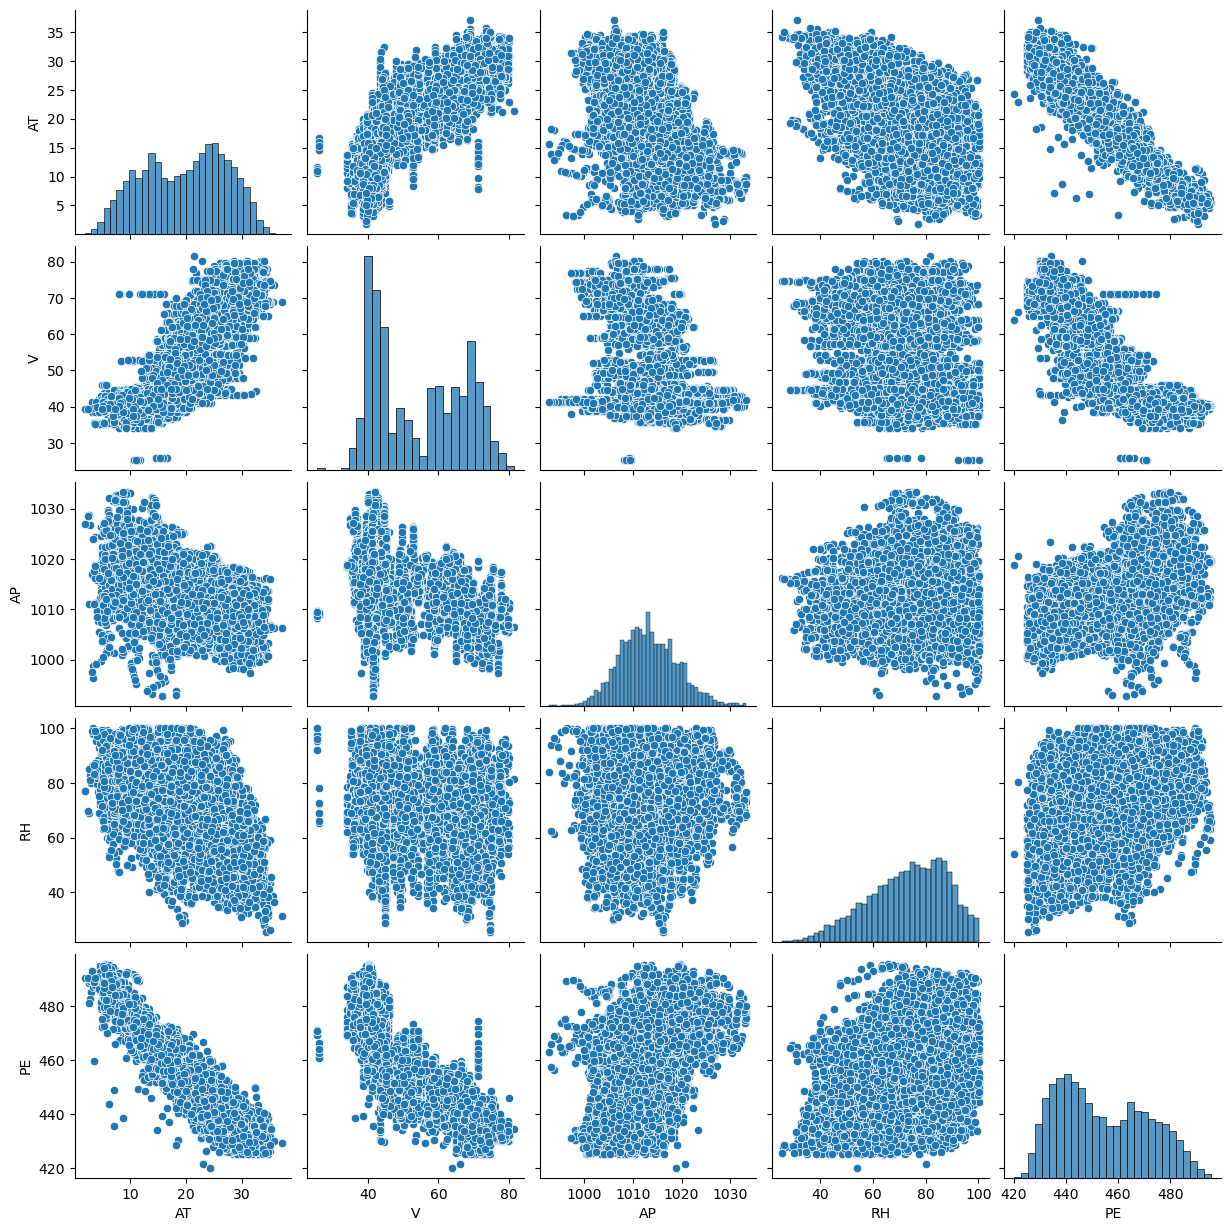

In [7]:
sns.pairplot(df)
plt.show()

### 1(b)(ii)

The pairwise scatterplots show several noticeable relationships among the variables.

- PE has a strong negative relationship with AT. As ambient temperature increases, electrical energy output generally decreases.
- PE also has a strong negative relationship with V. Higher exhaust vacuum is generally associated with lower electrical energy output.
- AP has a positive relationship with PE, although the relationship is weaker than the relationship between AT and PE.
- RH also shows a positive relationship with PE, but there is considerable variability.
- Among the predictors, AT and V have a strong positive relationship, while AT and RH show a negative relationship.
- Some of the relationships appear nonlinear, suggesting that nonlinear terms may be useful in later regression models.
- A few observations also appear separated from the main concentration of points and may be potential outliers.

In [9]:
summary_stats = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range': df.max() - df.min(),
    'First Quartile (Q1)': df.quantile(0.25),
    'Third Quartile (Q3)': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
})

summary_stats

,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### 1(b)(iii)

The following table summarizes the mean, median, range, first quartile (Q1), third quartile (Q3), and interquartile range (IQR) for each variable.

### 1(c) Simple Linear Regression

In [12]:
import statsmodels.api as sm

In [13]:
X = sm.add_constant(df['AT'])
y = df['PE']

model_AT = sm.OLS(y, X).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:11   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

In [14]:
X = sm.add_constant(df['V'])

model_V = sm.OLS(y, X).fit()
print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:12   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

In [15]:
X = sm.add_constant(df['AP'])

model_AP = sm.OLS(y, X).fit()
print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:12   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

In [16]:
X = sm.add_constant(df['RH'])

model_RH = sm.OLS(y, X).fit()
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:12   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

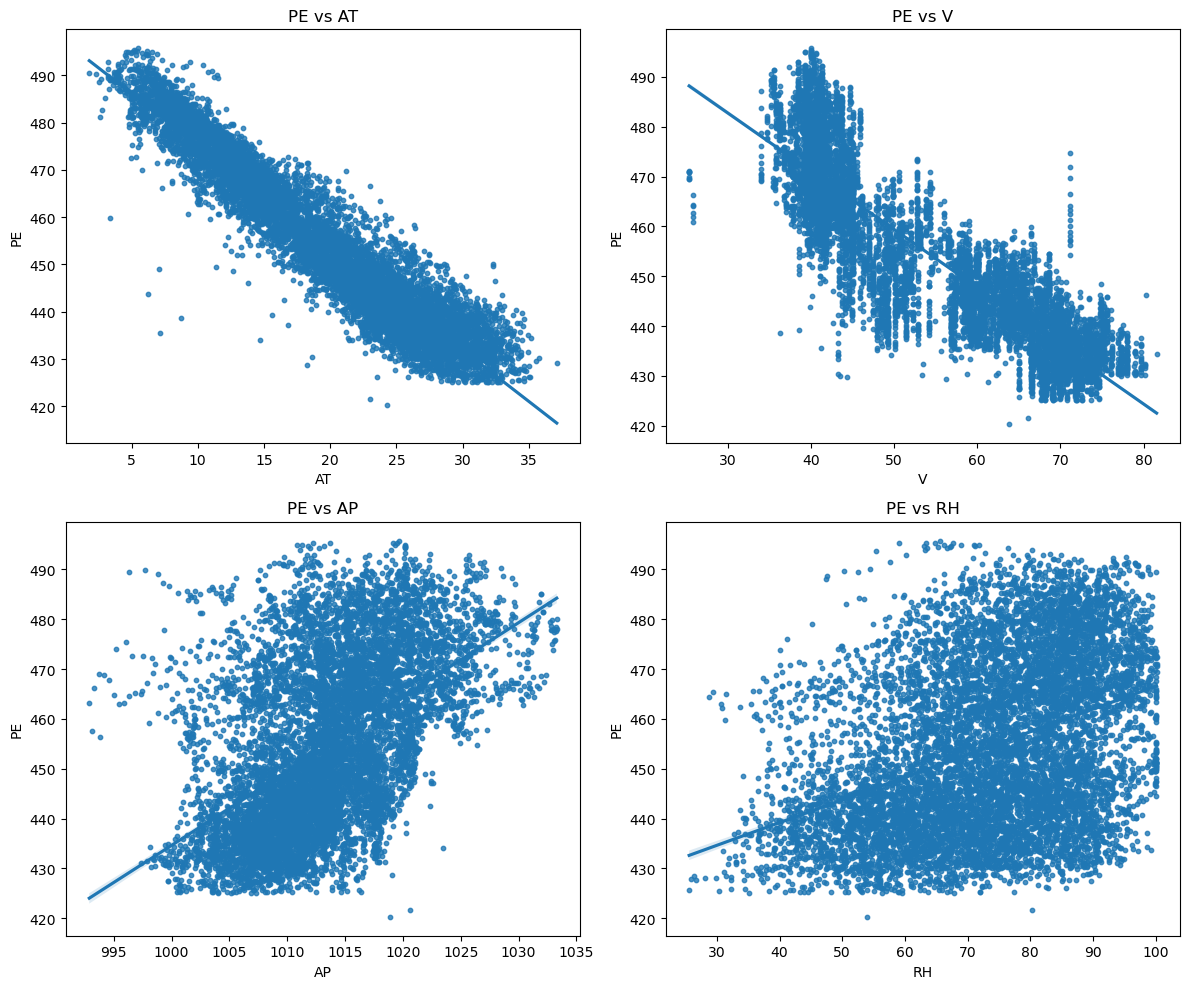

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.regplot(x='AT', y='PE', data=df, ax=axes[0, 0],
            scatter_kws={'s': 10})
axes[0, 0].set_title('PE vs AT')

sns.regplot(x='V', y='PE', data=df, ax=axes[0, 1],
            scatter_kws={'s': 10})
axes[0, 1].set_title('PE vs V')

sns.regplot(x='AP', y='PE', data=df, ax=axes[1, 0],
            scatter_kws={'s': 10})
axes[1, 0].set_title('PE vs AP')

sns.regplot(x='RH', y='PE', data=df, ax=axes[1, 1],
            scatter_kws={'s': 10})
axes[1, 1].set_title('PE vs RH')

plt.tight_layout()
plt.show()

#### Results

Simple linear regression models were fitted separately using AT, V, AP, and RH to predict PE.

- *AT:* The estimated coefficient is -2.1713 with p < 0.001 and R² = 0.899. Therefore, AT has a statistically significant negative association with PE. A one-unit increase in AT is associated with an estimated 2.1713-unit decrease in PE.
- *V:* The estimated coefficient is -1.1681 with p < 0.001 and R² = 0.757. Therefore, V has a statistically significant negative association with PE.
- *AP:* The estimated coefficient is 1.4899 with p < 0.001 and R² = 0.269. Therefore, AP has a statistically significant positive association with PE.
- *RH:* The estimated coefficient is 0.4557 with p < 0.001 and R² = 0.152. Therefore, RH has a statistically significant positive association with PE.

Thus, all four predictors have statistically significant associations with PE when considered individually. Among the four simple linear regression models, AT has the highest R² and therefore explains the largest proportion of the variation in PE.

The regression plots also show some observations that lie relatively far from the fitted regression lines, particularly for AT and V. These may be potential outliers. However, they should not automatically be removed because there is no evidence that they are data-entry or measurement errors. Therefore, I would retain the observations unless further diagnostic analysis provides a justified reason for removing them.

### 1(d) Multiple Linear Regression

In [20]:
X = df[['AT', 'V', 'AP', 'RH']]
X = sm.add_constant(X)
y = df['PE']

model_multiple = sm.OLS(y, X).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

#### Results

The multiple linear regression model using AT, V, AP, and RH has an R² of 0.929, indicating that approximately 92.9% of the variability in PE is explained by the four predictors together.

The estimated regression coefficients are:

- AT: -1.9775 (p < 0.001)
- V: -0.2339 (p < 0.001)
- AP: 0.0621 (p < 0.001)
- RH: -0.1581 (p < 0.001)

Since the p-values for all four predictors are less than 0.05, we reject the null hypothesis H0: βj = 0 for AT, V, AP, and RH. Therefore, all four predictors have statistically significant associations with PE when the other predictors are held constant.

### 1(e) Comparison of Simple and Multiple Regression Coefficients

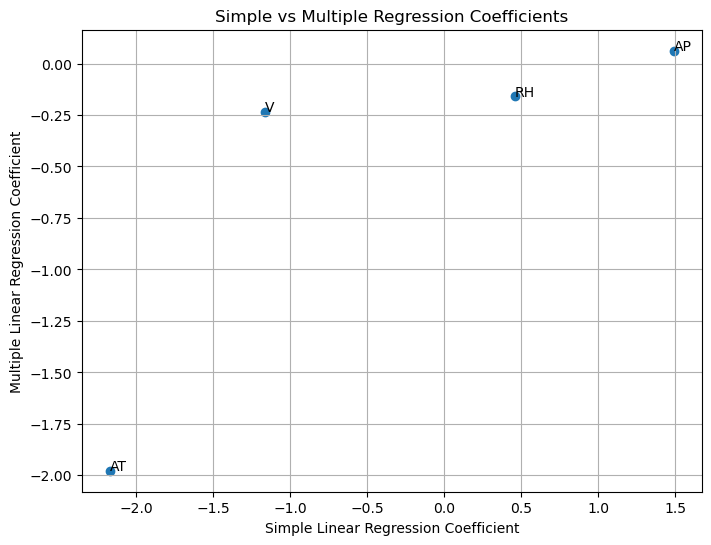

In [23]:
predictors = ['AT', 'V', 'AP', 'RH']

simple_coefs = [
    model_AT.params['AT'],
    model_V.params['V'],
    model_AP.params['AP'],
    model_RH.params['RH']
]

multiple_coefs = [
    model_multiple.params['AT'],
    model_multiple.params['V'],
    model_multiple.params['AP'],
    model_multiple.params['RH']
]

plt.figure(figsize=(8, 6))
plt.scatter(simple_coefs, multiple_coefs)

for i, predictor in enumerate(predictors):
    plt.annotate(predictor, (simple_coefs[i], multiple_coefs[i]))

plt.xlabel('Simple Linear Regression Coefficient')
plt.ylabel('Multiple Linear Regression Coefficient')
plt.title('Simple vs Multiple Regression Coefficients')
plt.grid(True)
plt.show()

#### Results

The coefficients from the simple and multiple linear regression models differ because the simple regressions consider each predictor separately, while the multiple regression estimates the effect of each predictor while holding the other predictors constant.

AT has a similar negative coefficient in both models (-2.1713 in the simple regression and -1.9775 in the multiple regression).

The coefficient for V changes from -1.1681 in the simple regression to -0.2339 in the multiple regression, showing a substantial decrease in magnitude.

The coefficient for AP changes from 1.4899 to 0.0621, also showing a substantial decrease in magnitude.

The most noticeable change occurs for RH. Its coefficient changes from 0.4557 in the simple regression to -0.1581 in the multiple regression, meaning that the direction of the estimated association changes after controlling for the other predictors.

These differences occur because the predictors are correlated with one another. Therefore, the simple regression coefficients can reflect both the predictor's association with PE and relationships shared with other predictors, whereas the multiple regression coefficients estimate each predictor's association with PE while controlling for the others.

### 1(f) Nonlinear Associations

In [26]:
X_AT_poly = pd.DataFrame({
    'AT': df['AT'],
    'AT^2': df['AT'] ** 2,
    'AT^3': df['AT'] ** 3
})

X_AT_poly = sm.add_constant(X_AT_poly)

model_AT_poly = sm.OLS(df['PE'], X_AT_poly).fit()

print(model_AT_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

In [27]:
X_V_poly = pd.DataFrame({
    'V': df['V'],
    'V^2': df['V'] ** 2,
    'V^3': df['V'] ** 3
})

X_V_poly = sm.add_constant(X_V_poly)

model_V_poly = sm.OLS(df['PE'], X_V_poly).fit()

print(model_V_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

In [28]:
X_AP_poly = pd.DataFrame({
    'AP': df['AP'],
    'AP^2': df['AP'] ** 2,
    'AP^3': df['AP'] ** 3
})

X_AP_poly = sm.add_constant(X_AP_poly)

model_AP_poly = sm.OLS(df['PE'], X_AP_poly).fit()

print(model_AP_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.009      8.415      0.0

In [29]:
X_RH_poly = pd.DataFrame({
    'RH': df['RH'],
    'RH^2': df['RH'] ** 2,
    'RH^3': df['RH'] ** 3
})

X_RH_poly = sm.add_constant(X_RH_poly)

model_RH_poly = sm.OLS(df['PE'], X_RH_poly).fit()

print(model_RH_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

#### Results

To investigate nonlinear associations between each predictor and PE, cubic polynomial regression models containing X, X², and X³ were fitted separately for each predictor.

- *AT:* Both AT² and AT³ are statistically significant (p < 0.001), providing evidence of a nonlinear association between AT and PE.
- *V:* V² is not statistically significant (p = 0.768), but V³ is statistically significant (p = 0.014). Therefore, there is evidence of a nonlinear association between V and PE.
- *AP:* Both AP² and AP³ are statistically significant (p < 0.001), providing evidence of a nonlinear association between AP and PE.
- *RH:* Both RH² and RH³ are statistically significant (p < 0.001), providing evidence of a nonlinear association between RH and PE.

Overall, there is evidence of nonlinear association between each of the four predictors and PE, although the evidence for V comes from the significant cubic term rather than the quadratic term.

### 1(g) Interaction Effects

In [32]:
import statsmodels.formula.api as smf

model_interactions = smf.ols(
    'PE ~ AT * V + AT * AP + AT * RH + V * AP + V * RH + AP * RH',
    data=df
).fit()

print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:13   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

#### Results

A multiple linear regression model containing all pairwise interaction terms among AT, V, AP, and RH was fitted to predict PE.

The interaction terms have the following results:

- AT:V is statistically significant (p < 0.001).
- AT:AP is not statistically significant (p = 0.452).
- AT:RH is statistically significant (p < 0.001).
- V:AP is statistically significant (p < 0.001).
- V:RH is not statistically significant (p = 0.086).
- AP:RH is statistically significant (p = 0.034).

Therefore, there is evidence of interaction effects between AT and V, AT and RH, V and AP, and AP and RH. There is not sufficient evidence of interaction effects for AT and AP or V and RH at the 0.05 significance level.

### 1(h) Model Improvement and Train-Test MSE

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training set size:", train_df.shape)
print("Test set size:", test_df.shape)

Training set size: (6697, 5)
Test set size: (2871, 5)


In [36]:
linear_model = smf.ols(
    'PE ~ AT + V + AP + RH',
    data=train_df
).fit()

train_pred = linear_model.predict(train_df)
test_pred = linear_model.predict(test_df)

linear_train_mse = mean_squared_error(train_df['PE'], train_pred)
linear_test_mse = mean_squared_error(test_df['PE'], test_pred)

print("Linear Regression Train MSE:", linear_train_mse)
print("Linear Regression Test MSE:", linear_test_mse)

Linear Regression Train MSE: 20.58083972573871
Linear Regression Test MSE: 21.239856938225284


In [37]:
train_df = train_df.copy()
test_df = test_df.copy()

train_df['AT2'] = train_df['AT'] ** 2
train_df['V2'] = train_df['V'] ** 2
train_df['AP2'] = train_df['AP'] ** 2
train_df['RH2'] = train_df['RH'] ** 2

test_df['AT2'] = test_df['AT'] ** 2
test_df['V2'] = test_df['V'] ** 2
test_df['AP2'] = test_df['AP'] ** 2
test_df['RH2'] = test_df['RH'] ** 2

full_model = smf.ols(
    '''PE ~ AT + V + AP + RH
       + AT2 + V2 + AP2 + RH2
       + AT:V + AT:AP + AT:RH
       + V:AP + V:RH + AP:RH''',
    data=train_df
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:14   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

In [38]:
reduced_model = smf.ols(
    '''PE ~ AT + V + AP + RH
       + AT2 + AP2 + RH2
       + AT:V + AT:RH + AP:RH''',
    data=train_df
).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:14   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.046e+04   1091.512     -9.581      0.0

In [39]:
reduced_train_pred = reduced_model.predict(train_df)
reduced_test_pred = reduced_model.predict(test_df)

reduced_train_mse = mean_squared_error(
    train_df['PE'], reduced_train_pred
)

reduced_test_mse = mean_squared_error(
    test_df['PE'], reduced_test_pred
)

print("Reduced Model Train MSE:", reduced_train_mse)
print("Reduced Model Test MSE:", reduced_test_mse)

Reduced Model Train MSE: 17.917812671185754
Reduced Model Test MSE: 18.694346190799298


#### Results

The data were randomly divided into 70% training data and 30% test data.

The multiple linear regression model using AT, V, AP, and RH produced:

- Training MSE = 20.5808
- Test MSE = 21.2399

A larger model containing all pairwise interactions and quadratic terms was then fitted to the training data. Insignificant higher-order terms were removed based on their p-values while maintaining the appropriate lower-order terms required by the hierarchy principle.

The reduced model retained the significant quadratic terms AT², AP², and RH² and the significant interactions AT:V, AT:RH, and AP:RH, while maintaining the necessary lower-order terms according to the hierarchy principle.

The reduced model produced:

- Training MSE = 17.9178
- Test MSE = 18.6943

The reduced nonlinear/interaction model has lower training and test MSEs than the ordinary multiple linear regression model. Therefore, including appropriate nonlinear and interaction terms improves the predictive performance of the model on this train-test split.


### 1(i) KNN Regression

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train = train_df[['AT', 'V', 'AP', 'RH']]
y_train = train_df['PE']

X_test = test_df[['AT', 'V', 'AP', 'RH']]
y_test = test_df['PE']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6697, 4)
X_test shape: (2871, 4)


In [43]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_predictions = knn.predict(X_train)
    test_predictions = knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, train_predictions)
    )
    raw_test_mse.append(
        mean_squared_error(y_test, test_predictions)
    )

best_k_raw = k_values[np.argmin(raw_test_mse)]

print("Best k for raw features:", best_k_raw)
print("Minimum raw test MSE:", min(raw_test_mse))

Best k for raw features: 5
Minimum raw test MSE: 15.726819842563568


In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_predictions = knn.predict(X_train_scaled)
    test_predictions = knn.predict(X_test_scaled)

    normalized_train_mse.append(
        mean_squared_error(y_train, train_predictions)
    )
    normalized_test_mse.append(
        mean_squared_error(y_test, test_predictions)
    )

best_k_normalized = k_values[np.argmin(normalized_test_mse)]

print("Best k for normalized features:", best_k_normalized)
print("Minimum normalized test MSE:", min(normalized_test_mse))

Best k for normalized features: 4
Minimum normalized test MSE: 14.305669422675024


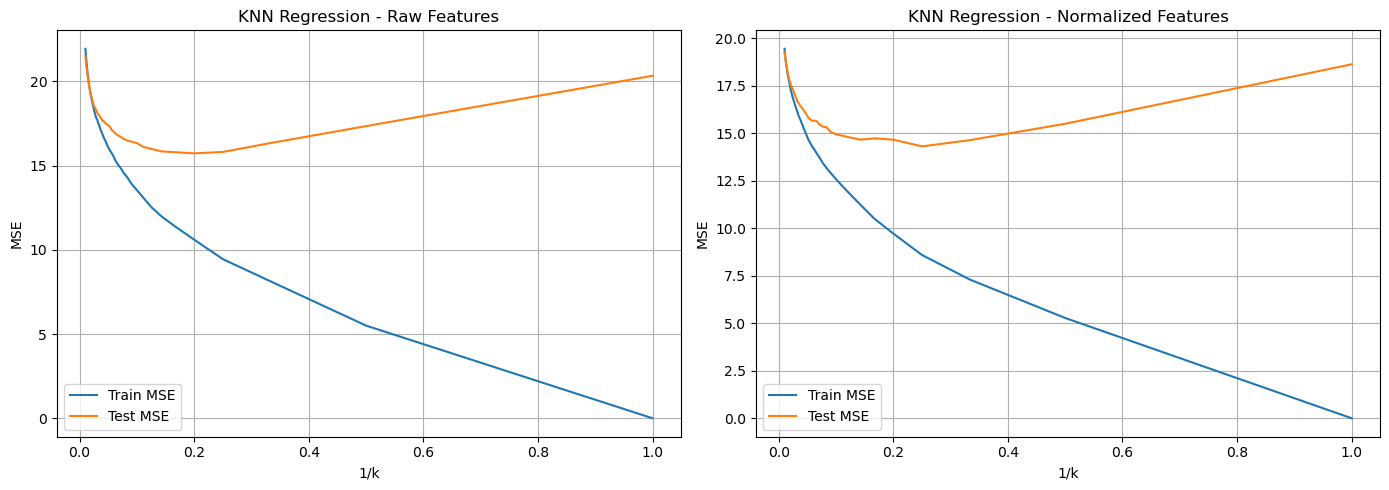

In [45]:
inverse_k = [1/k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw features
axes[0].plot(inverse_k, raw_train_mse, label='Train MSE')
axes[0].plot(inverse_k, raw_test_mse, label='Test MSE')
axes[0].set_xlabel('1/k')
axes[0].set_ylabel('MSE')
axes[0].set_title('KNN Regression - Raw Features')
axes[0].legend()
axes[0].grid(True)

# Normalized features
axes[1].plot(inverse_k, normalized_train_mse, label='Train MSE')
axes[1].plot(inverse_k, normalized_test_mse, label='Test MSE')
axes[1].set_xlabel('1/k')
axes[1].set_ylabel('MSE')
axes[1].set_title('KNN Regression - Normalized Features')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Results

KNN regression was performed for k values from 1 to 100 using both raw and normalized predictor variables.

For the raw features, the minimum test MSE was 15.7268, obtained at k = 5.

For the normalized features, the minimum test MSE was 14.3057, obtained at k = 4.

The normalized KNN model achieved a lower minimum test MSE than the KNN model using raw features. This is expected because KNN is based on distances between observations, and normalization prevents variables with larger numerical scales from dominating the distance calculation.

The plots show the training and test MSEs as functions of 1/k. Very small values of k produce very low training error but higher test error, indicating overfitting. As k increases, the training error increases, while the test error initially decreases and then increases. The minimum test error provides the selected value of k.

### 1(j) Comparison of KNN and Regression

Among the regression models, the reduced model containing selected interaction and quadratic terms achieved the lowest test MSE of 18.6943.

For KNN regression, the raw-feature model achieved a minimum test MSE of 15.7268 at k = 5, while the normalized-feature model achieved a minimum test MSE of 14.3057 at k = 4.

Therefore, on this train-test split, the normalized KNN model achieved a lower test MSE than the best regression model (14.3057 compared with 18.6943). The raw-feature KNN model also had a lower test MSE than the regression model.

These results suggest that KNN is able to capture relationships in the data that are not fully represented by the fitted regression models. Normalization further improves KNN performance because KNN relies on distances between observations, and scaling prevents predictors with larger numerical ranges from dominating the distance calculation.

## 2. ISLR 2.4.1

For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

### (a) The sample size n is extremely large, and the number of predictors p is small.
A flexible statistical learning method would generally perform better than an inflexible method. Since the sample size is extremely large and the number of predictors is small, there is enough data to fit a flexible model without a high risk of overfitting. The flexible method can capture more complex relationships between the predictors and the response.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible statistical learning method would generally perform worse than an inflexible method. When the number of predictors is extremely large and the number of observations is small, a flexible method is more likely to overfit the limited training data. An inflexible method has lower variance and is generally less prone to overfitting in this situation.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible statistical learning method would generally perform better than an inflexible method. When the relationship between the predictors and the response is highly nonlinear, a flexible method can adapt to and capture the complex nonlinear relationship, whereas an inflexible method may be too restrictive.

### (d) The variance of the error terms, i.e. σ² = Var(ε), is extremely high.

A flexible statistical learning method would generally perform worse than an inflexible method. When the variance of the error terms is extremely high, the data contain a large amount of noise. A flexible method is more likely to fit this noise, leading to overfitting and high variance. An inflexible method is less likely to fit the noise and may therefore perform better on unseen data.

## 3. ISLR 2.4.7

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | X1 | X2 | X3 | Y |
|------|----|----|----|-------|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distance is calculated as:

d = √[(X1 - 0)² + (X2 - 0)² + (X3 - 0)²]

- Observation 1: √(0² + 3² + 0²) = 3
- Observation 2: √(2² + 0² + 0²) = 2
- Observation 3: √(0² + 1² + 3²) = √10 ≈ 3.162
- Observation 4: √(0² + 1² + 2²) = √5 ≈ 2.236
- Observation 5: √((-1)² + 0² + 1²) = √2 ≈ 1.414
- Observation 6: √(1² + 1² + 1²) = √3 ≈ 1.732

### (b) What is our prediction with K = 1? Why?

For K = 1, the prediction is *Green*.

The nearest observation to the test point (0, 0, 0) is Observation 5, which has a Euclidean distance of √2 ≈ 1.414. Since Observation 5 has response Y = Green, the KNN prediction for K = 1 is Green.

### (c) What is our prediction with K = 3? Why?

For K = 3, the prediction is *Red*.

The three nearest observations to the test point (0, 0, 0) are:

- Observation 5: distance = √2 ≈ 1.414, Y = Green
- Observation 6: distance = √3 ≈ 1.732, Y = Red
- Observation 2: distance = 2, Y = Red

Among the three nearest neighbors, two are Red and one is Green. Therefore, by majority vote, the KNN prediction for K = 3 is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best value of K to be *small*.

A small value of K makes the KNN classifier more flexible and allows it to capture a highly non-linear decision boundary. A large value of K produces a smoother and less flexible decision boundary, which may fail to capture complex patterns in the data.